In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [2]:
path = kagglehub.dataset_download(
    "uciml/breast-cancer-wisconsin-data")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "data.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
📁 Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data

✅ Dataset Loaded!
📐 Shape: 569 rows × 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,569.0,NaN,NaN,NaN,30371831.432337,125020585.612224,8670.0,869218.0,906024.0,8813129.0,911320502.0
diagnosis,569,2,B,357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
radius_mean,569.0,NaN,NaN,NaN,14.127292,3.524049,6.981,11.7,13.37,15.78,28.11
texture_mean,569.0,NaN,NaN,NaN,19.289649,4.301036,9.71,16.17,18.84,21.8,39.28
perimeter_mean,569.0,NaN,NaN,NaN,91.969033,24.298981,43.79,75.17,86.24,104.1,188.5
area_mean,569.0,NaN,NaN,NaN,654.889104,351.914129,143.5,420.3,551.1,782.7,2501.0
smoothness_mean,569.0,NaN,NaN,NaN,0.09636,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,NaN,NaN,NaN,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,NaN,NaN,NaN,0.088799,0.07972,0.0,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,NaN,NaN,NaN,0.048919,0.038803,0.0,0.02031,0.0335,0.074,0.2012


In [5]:
num_features = df.select_dtypes(
    include=[np.number]).columns.tolist()
cat_features = df.select_dtypes(
    include=['object']).columns.tolist()

print(f"\n🔢 Numerical Columns ({len(num_features)}):")
print(num_features)

print(f"\n🔤 Categorical Columns ({len(cat_features)}):")
print(cat_features)

print(f"\n🎯 Target: diagnosis")
print(df['diagnosis'].value_counts())
print(f"\nB = Benign (সুস্থ), M = Malignant (ক্যান্সার)")


🔢 Numerical Columns (32):
['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

🔤 Categorical Columns (1):
['diagnosis']

🎯 Target: diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64

B = Benign (সুস্থ), M = Malignant (ক্যান্সার)


In [6]:
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    print("✅ 'id' column dropped")

✅ 'id' column dropped


In [7]:
unnamed_cols = [c for c in df.columns
                if 'Unnamed' in str(c)]
if unnamed_cols:
    df.drop(columns=unnamed_cols, inplace=True)
    print(f"✅ Dropped unnamed columns: {unnamed_cols}")

✅ Dropped unnamed columns: ['Unnamed: 32']


In [8]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])
    df.fillna(df.median(numeric_only=True), inplace=True)
    print("✅ Filled with median")

✅ No missing values found!


In [9]:
dups = df.duplicated().sum()
print(f"\n🔍 Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print("✅ Duplicates removed!")
else:
    print("✅ No duplicates found!")


🔍 Duplicate rows: 0
✅ No duplicates found!


In [10]:
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())
print("✅ Whitespace stripped")

✅ Whitespace stripped


In [11]:
print("\n🔍 Outlier Detection (IQR Method):")
num_cols = df.select_dtypes(
    include=[np.number]).columns.tolist()
outlier_info = {}

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower) | (df[col] > upper)].shape[0]
    if outliers > 0:
        outlier_info[col] = outliers

print(f"  Columns with outliers: {len(outlier_info)}")

# Cap outliers
for col in outlier_info.keys():
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(
        lower=Q1 - 1.5 * IQR,
        upper=Q3 + 1.5 * IQR)
print("✅ Outliers capped (Winsorization)")

print(f"\n📐 Cleaned Shape: {df.shape}")
df.head(3)


🔍 Outlier Detection (IQR Method):
  Columns with outliers: 29
✅ Outliers capped (Winsorization)

📐 Cleaned Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.22862,0.28241,0.14710,0.2419,...,25.38,17.33,184.6,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.8,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.5,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758


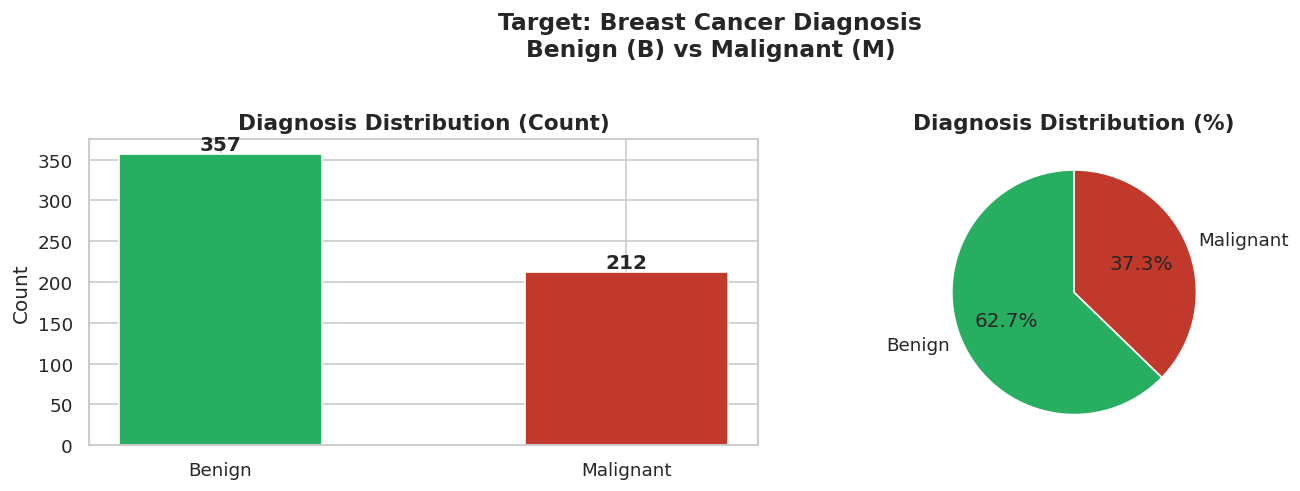

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

diag_counts = df['diagnosis'].value_counts()
labels_map  = {'B': 'Benign', 'M': 'Malignant'}
labels      = [labels_map[l] for l in diag_counts.index]

axes[0].bar(labels, diag_counts.values,
            color=['#27ae60', '#c0392b'],
            edgecolor='white', width=0.5)
axes[0].set_title('Diagnosis Distribution (Count)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(diag_counts.values):
    axes[0].text(i, v + 5, str(v),
                 ha='center', fontweight='bold')

axes[1].pie(diag_counts.values,
            labels=labels,
            autopct='%1.1f%%',
            colors=['#27ae60', '#c0392b'],
            startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Diagnosis Distribution (%)',
                  fontsize=13, fontweight='bold')

plt.suptitle('Target: Breast Cancer Diagnosis\n'
             'Benign (B) vs Malignant (M)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('SVM_01_diagnosis_distribution.png',
            bbox_inches='tight')
plt.show()

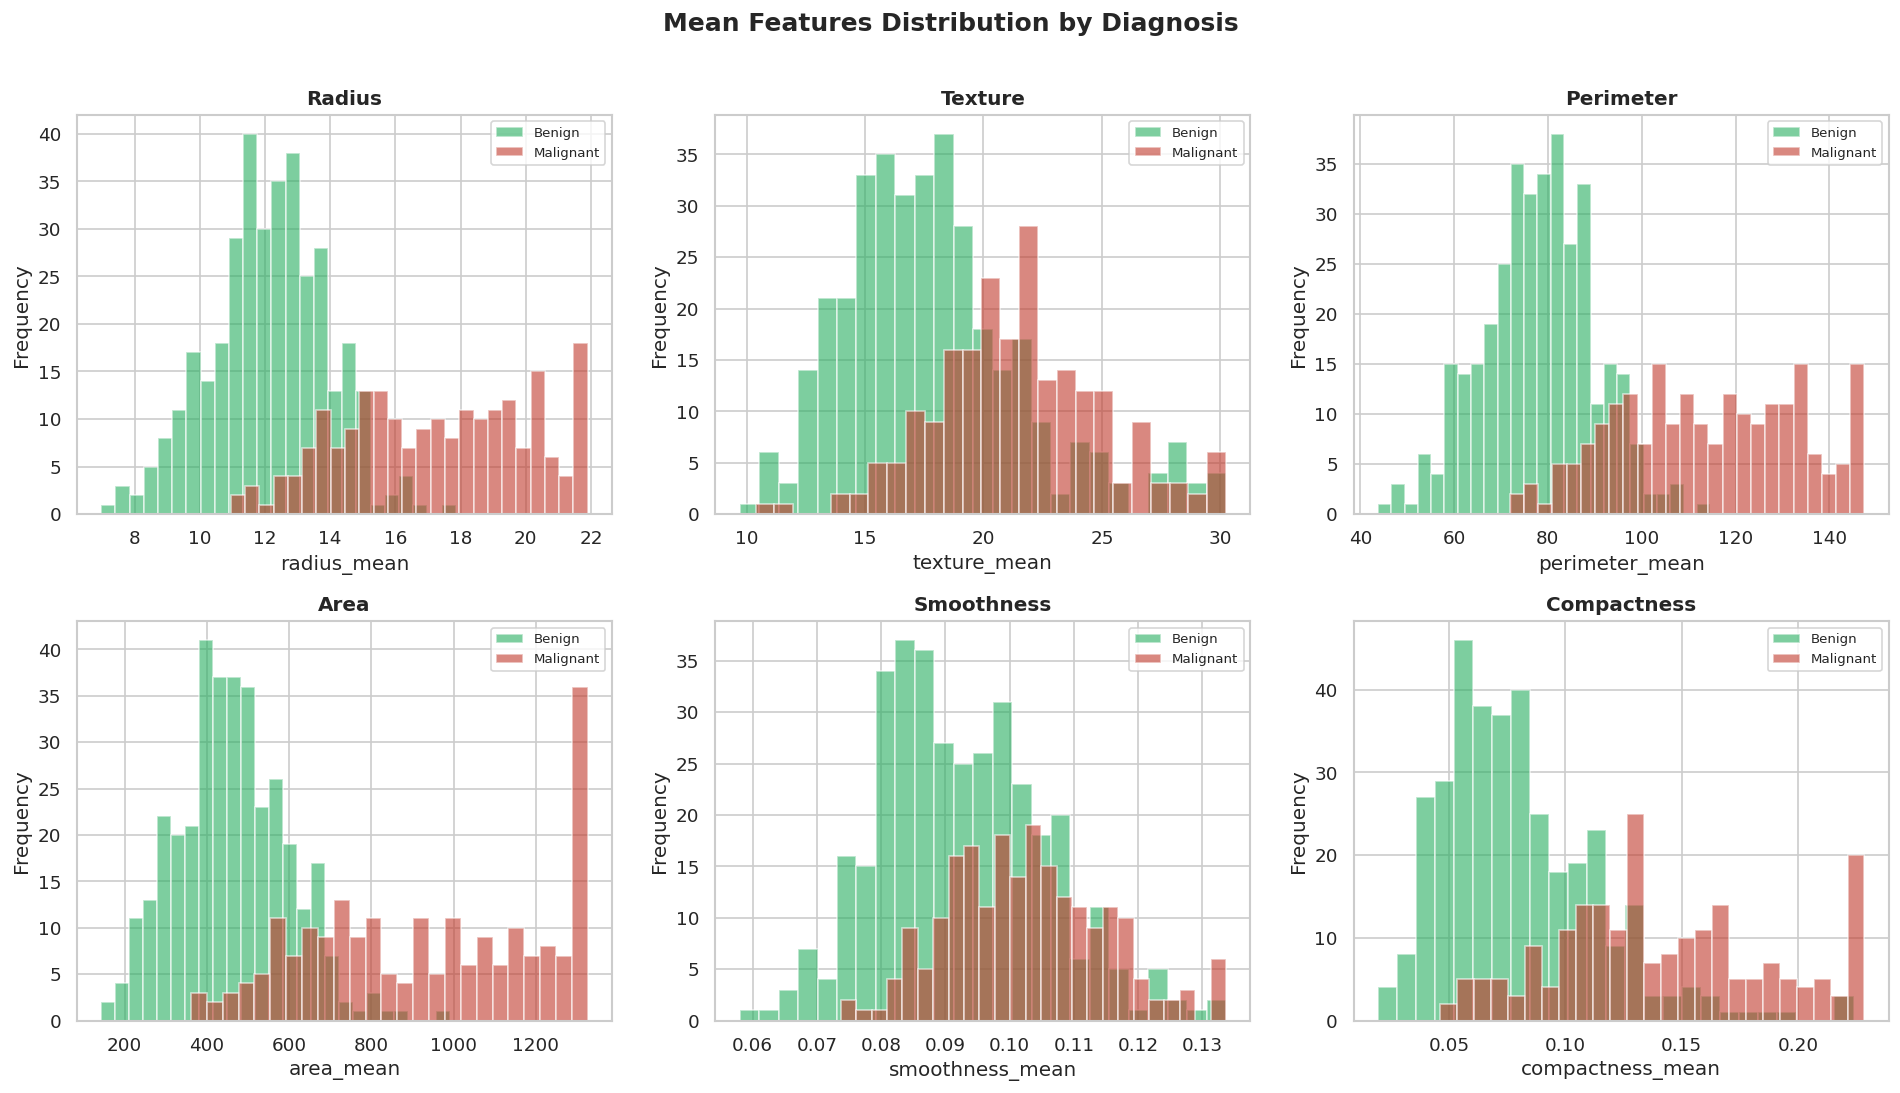

In [13]:
mean_cols = [c for c in df.columns if '_mean' in c][:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    axes[i].hist(
        df[df['diagnosis'] == 'B'][col],
        bins=25, alpha=0.6, color='#27ae60',
        label='Benign')
    axes[i].hist(
        df[df['diagnosis'] == 'M'][col],
        bins=25, alpha=0.6, color='#c0392b',
        label='Malignant')
    axes[i].set_title(col.replace('_mean', '').title(),
                      fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Mean Features Distribution by Diagnosis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('SVM_02_mean_features_dist.png',
            bbox_inches='tight')
plt.show()

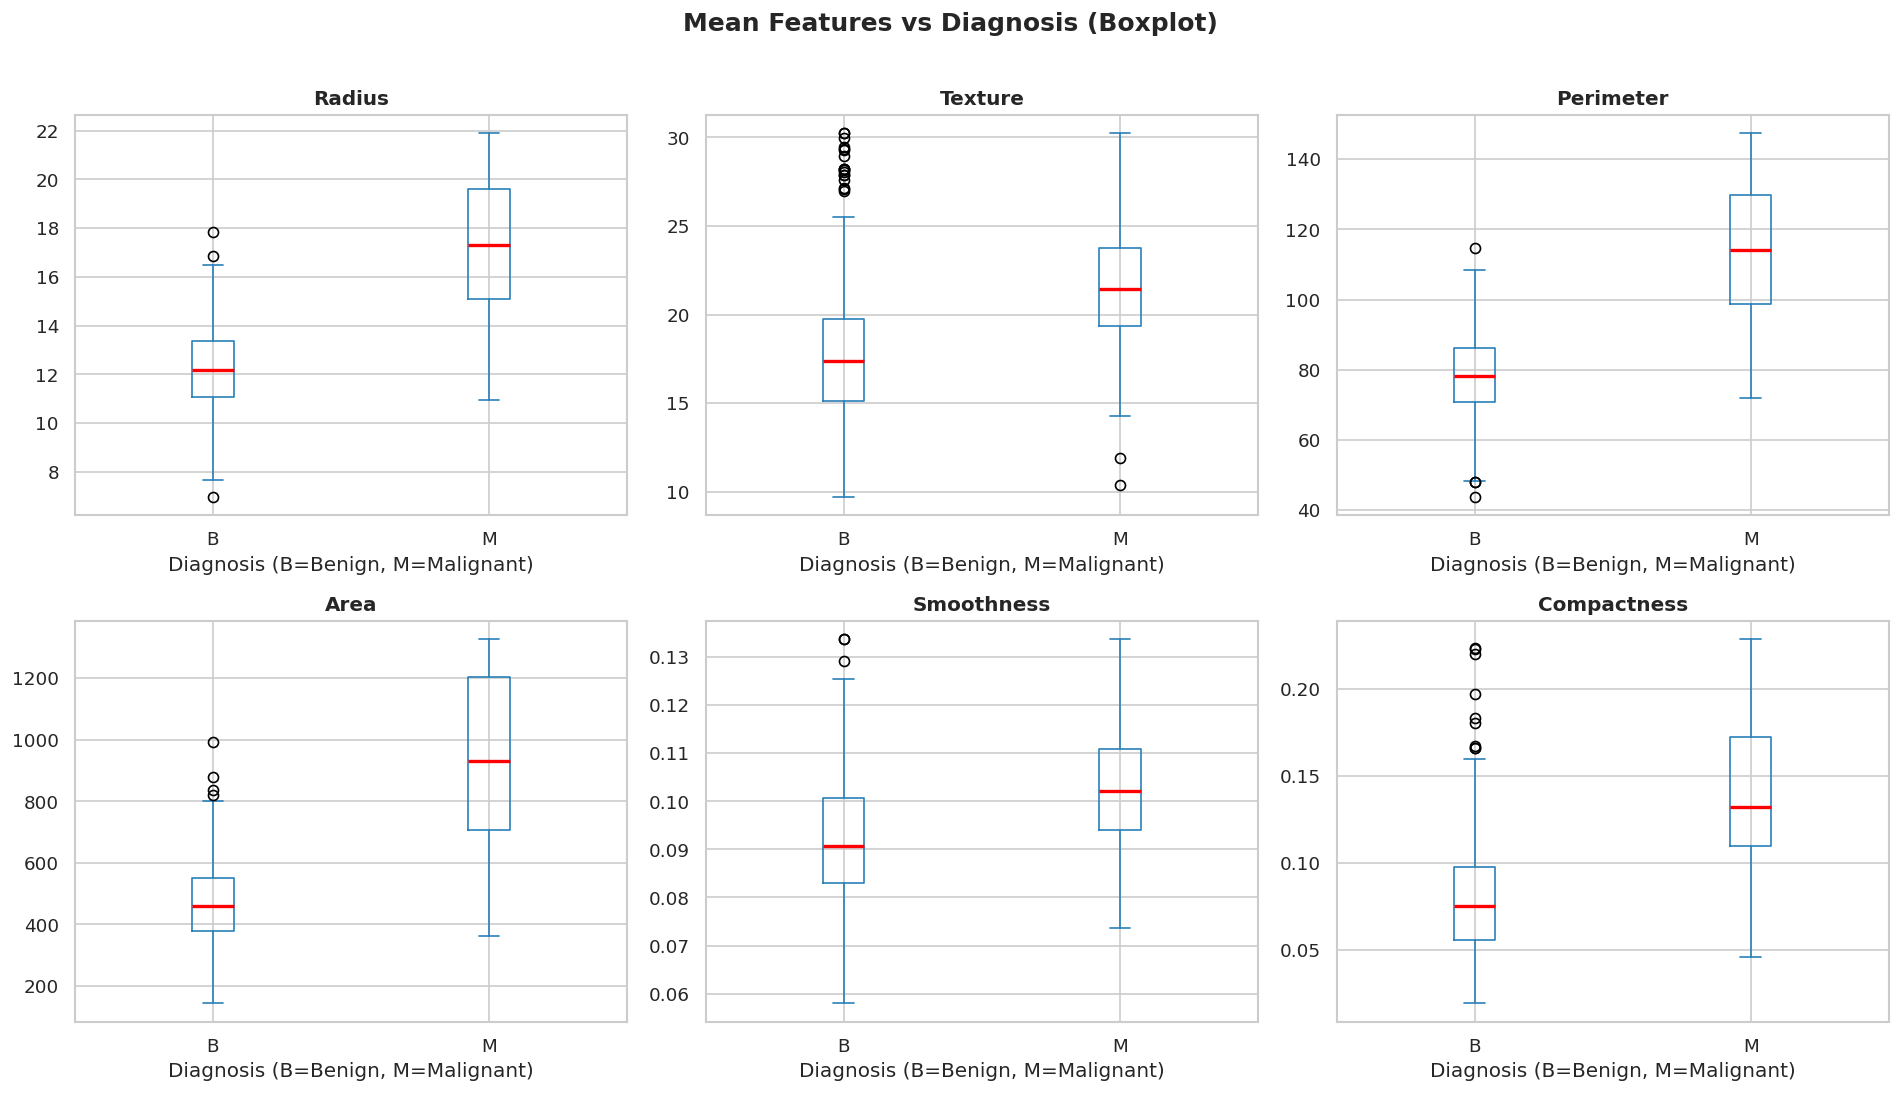

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(mean_cols):
    df.boxplot(column=col, by='diagnosis', ax=axes[i],
               boxprops=dict(color='#2980b9'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2980b9'),
               capprops=dict(color='#2980b9'))
    axes[i].set_title(col.replace('_mean', '').title(),
                      fontweight='bold')
    axes[i].set_xlabel('Diagnosis (B=Benign, M=Malignant)')

plt.suptitle('Mean Features vs Diagnosis (Boxplot)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('SVM_03_boxplots.png', bbox_inches='tight')
plt.show()

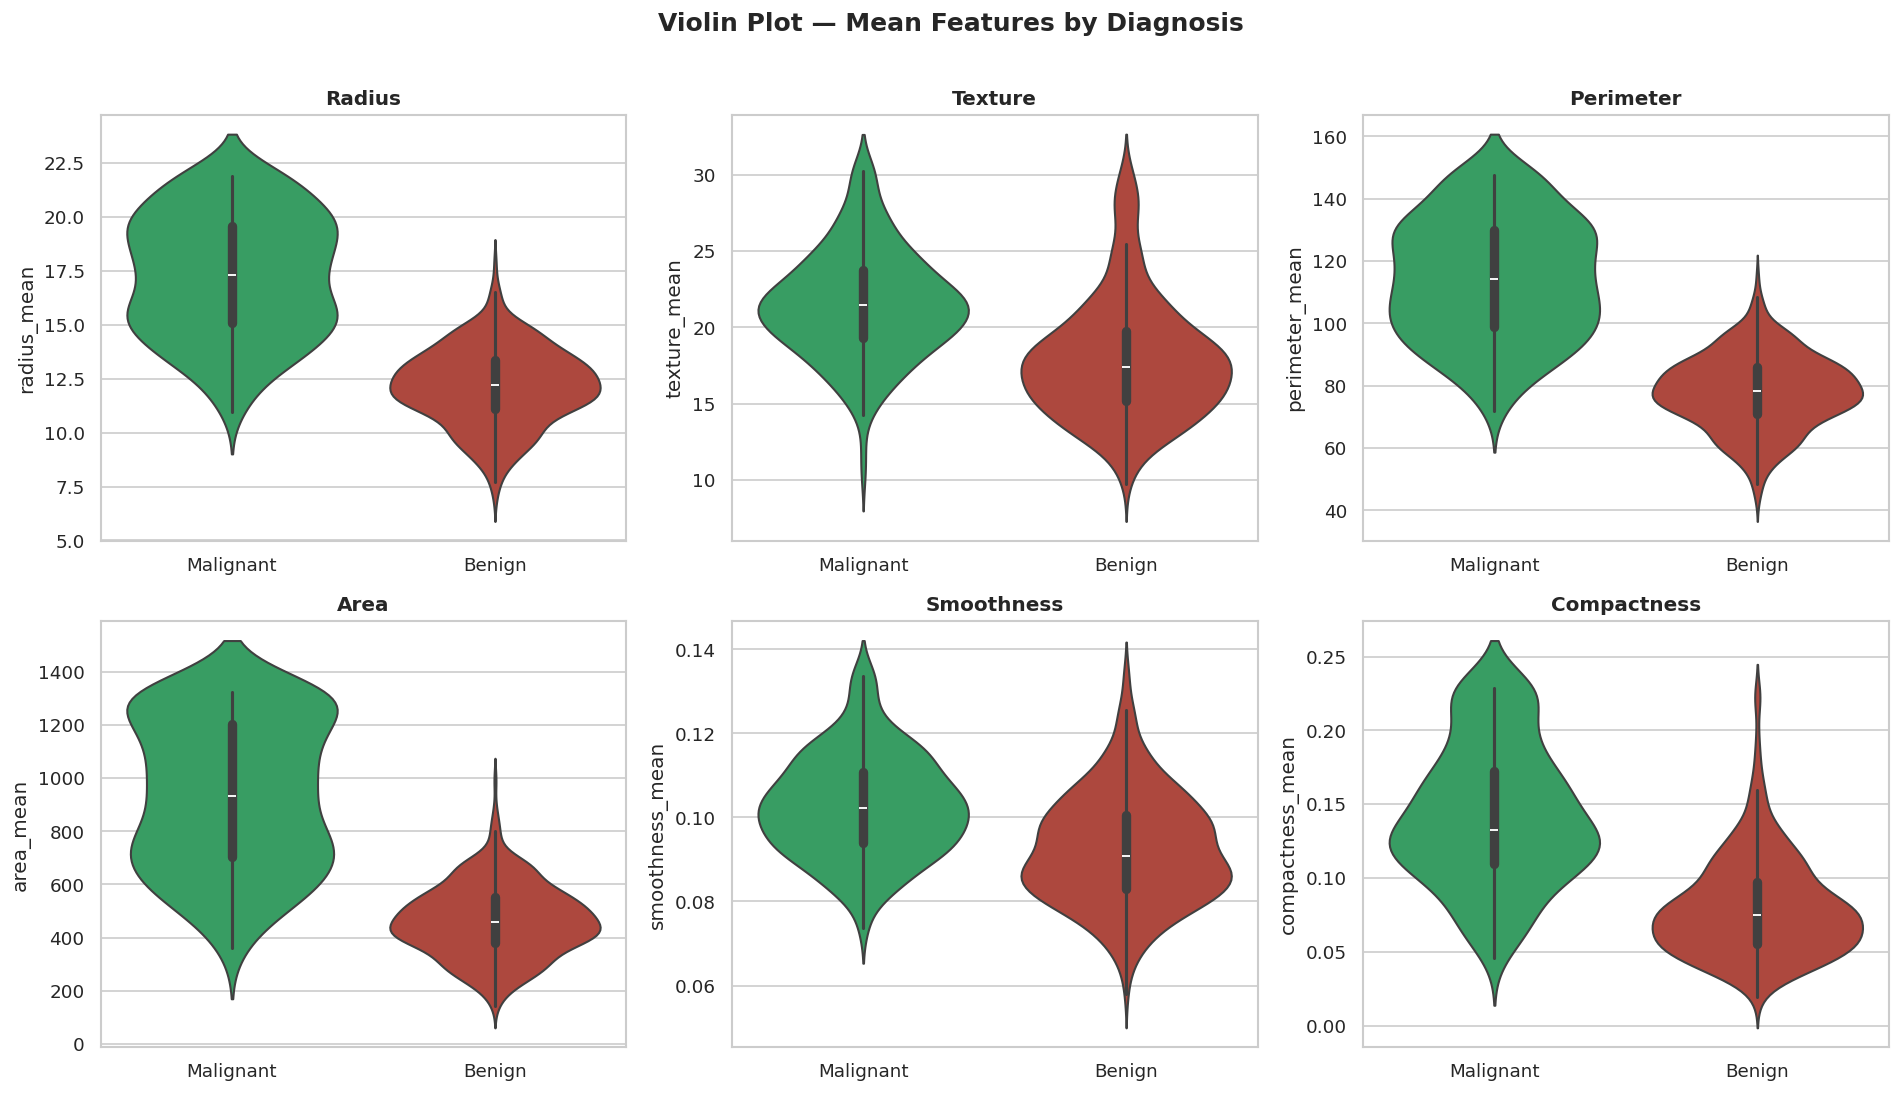

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

df_plot = df.copy()
df_plot['diagnosis_label'] = df_plot['diagnosis'].map(
    {'B': 'Benign', 'M': 'Malignant'})

for i, col in enumerate(mean_cols):
    sns.violinplot(
        data=df_plot, x='diagnosis_label', y=col,
        palette=['#27ae60', '#c0392b'],
        ax=axes[i], inner='box')
    axes[i].set_title(col.replace('_mean', '').title(),
                      fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Violin Plot — Mean Features by Diagnosis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('SVM_04_violin_plots.png', bbox_inches='tight')
plt.show()

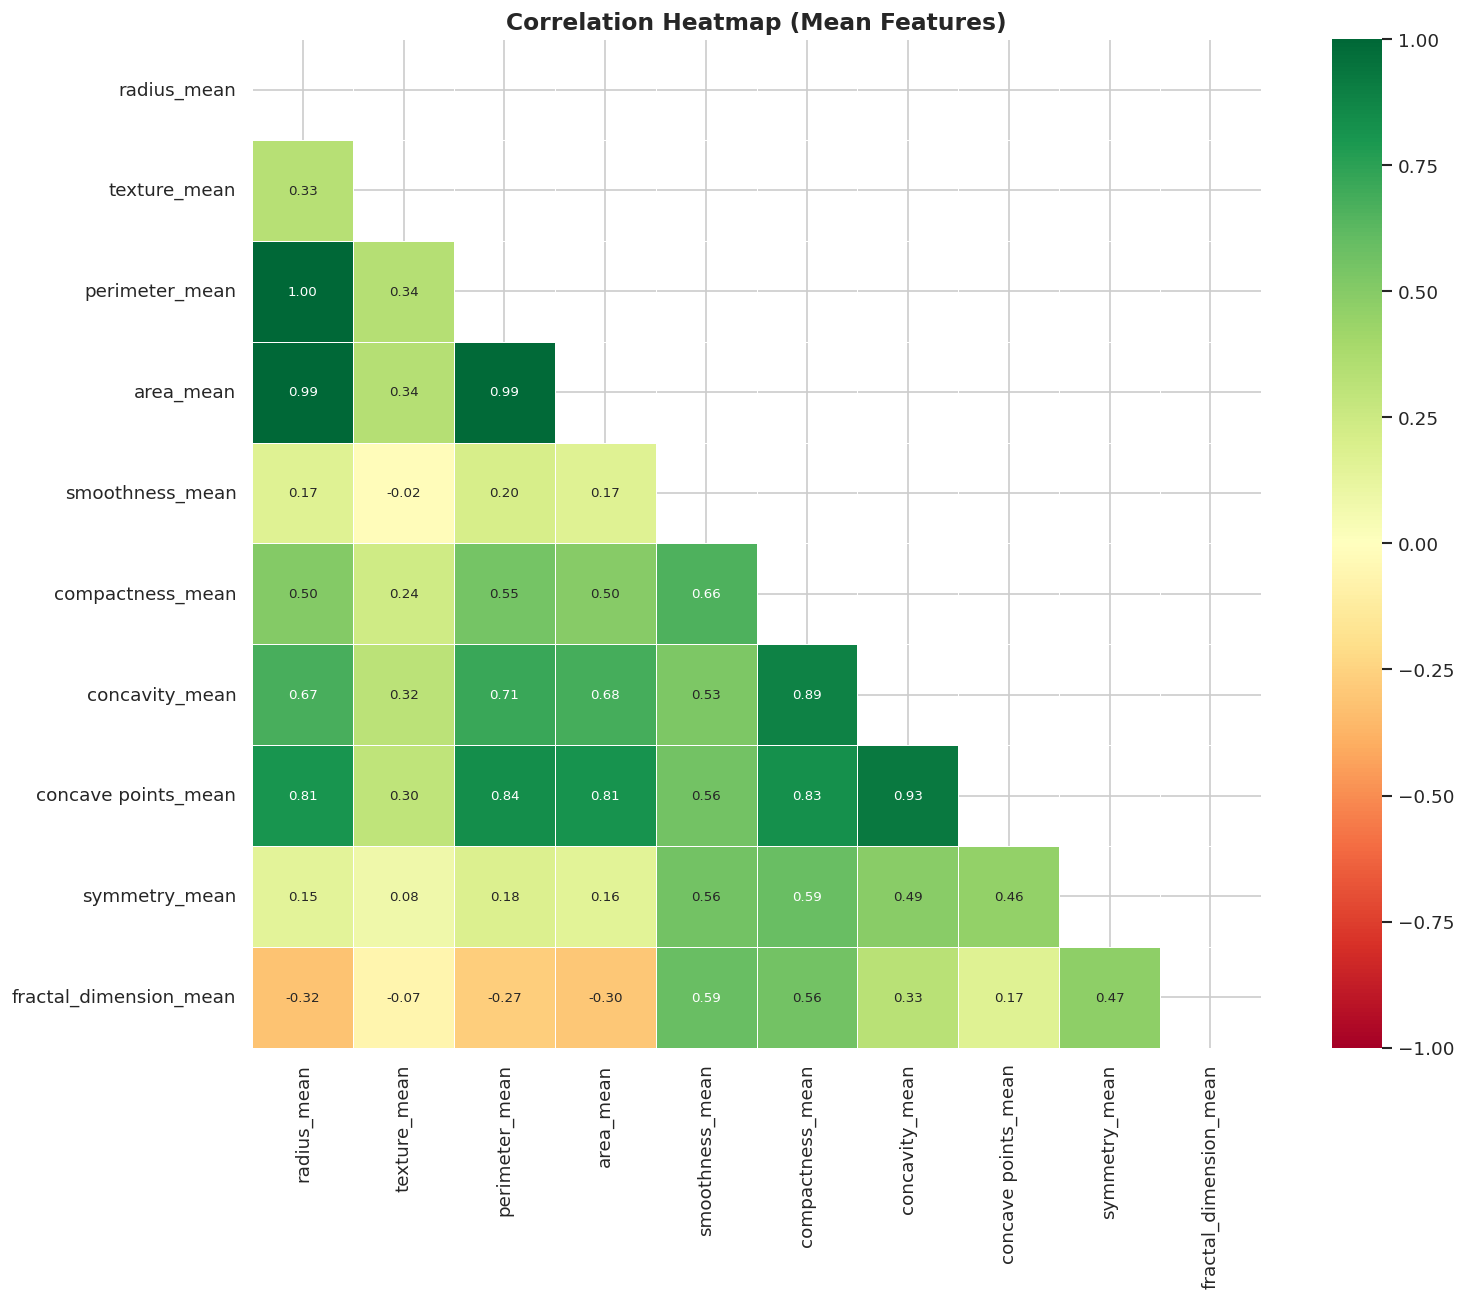

In [16]:
fig, ax = plt.subplots(figsize=(14, 11))

mean_df = df[mean_cols + [c for c in df.columns
                           if '_mean' in c]].copy()
mean_df = df[[c for c in df.columns
               if '_mean' in c]].copy()
corr    = mean_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.3, ax=ax,
            annot_kws={'fontsize': 8},
            vmin=-1, vmax=1, center=0, square=True)
ax.set_title('Correlation Heatmap (Mean Features)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SVM_05_correlation_heatmap.png',
            bbox_inches='tight')
plt.show()

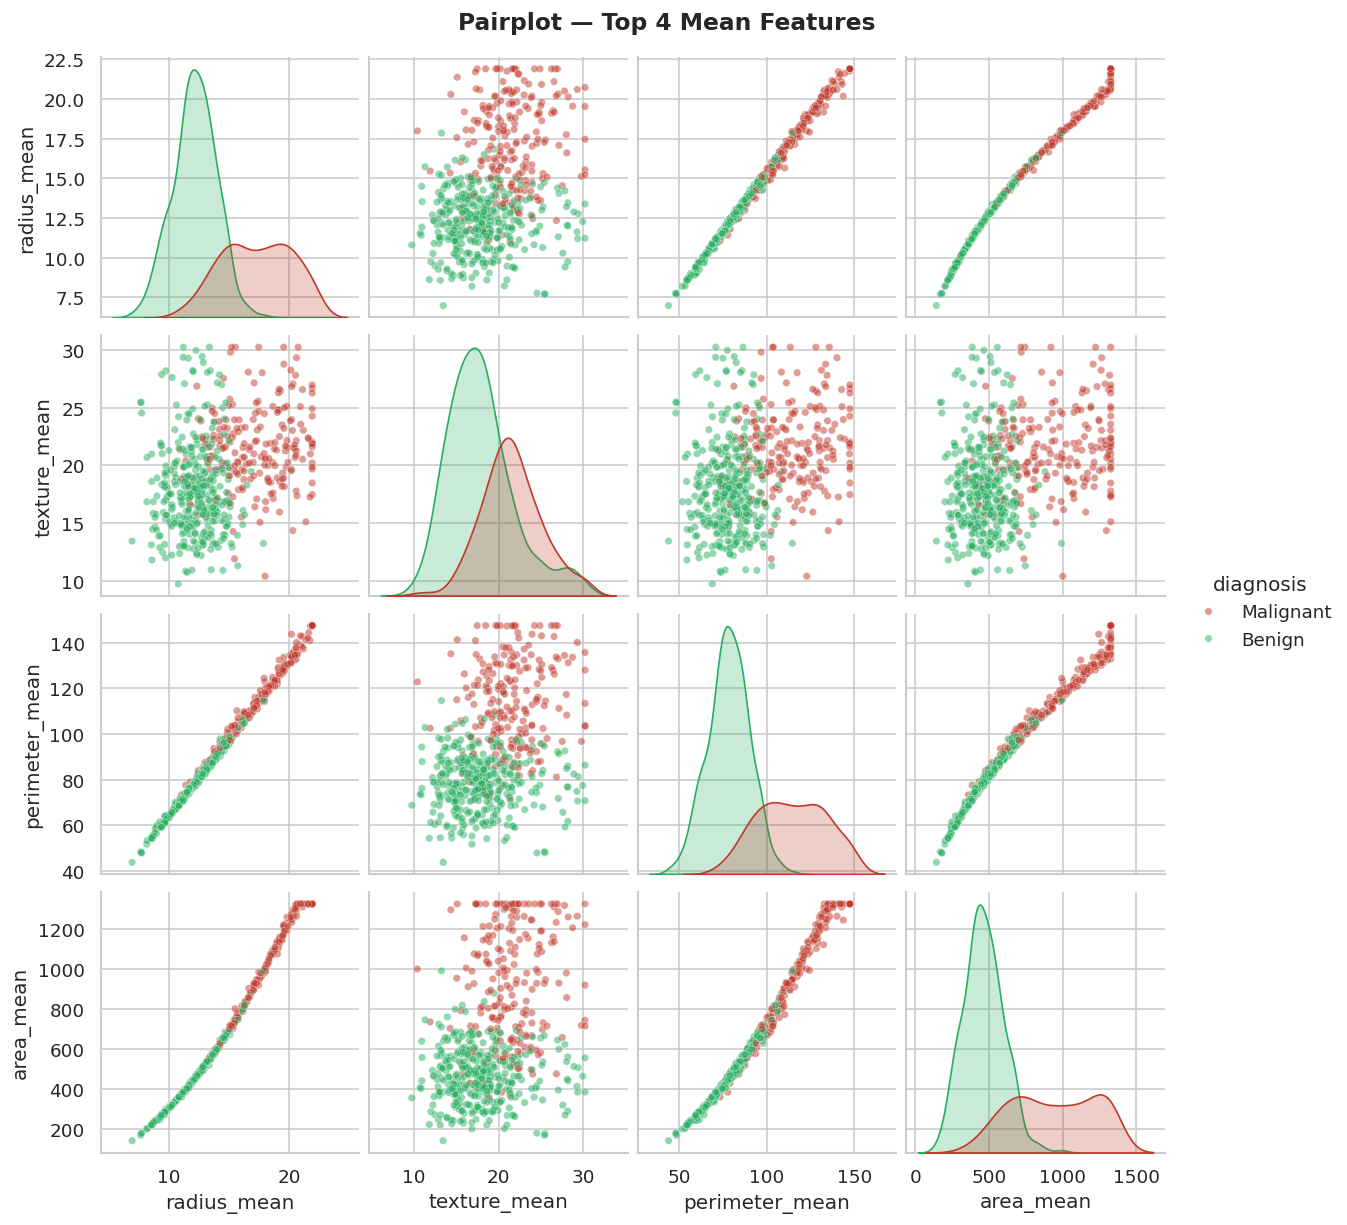

In [17]:
top4 = ['radius_mean', 'texture_mean',
        'perimeter_mean', 'area_mean']

df_pair = df[top4 + ['diagnosis']].copy()
df_pair['diagnosis'] = df_pair['diagnosis'].map(
    {'B': 'Benign', 'M': 'Malignant'})

pair_grid = sns.pairplot(
    df_pair, hue='diagnosis',
    palette={'Benign': '#27ae60', 'Malignant': '#c0392b'},
    plot_kws={'alpha': 0.5, 's': 20},
    diag_kind='kde')
pair_grid.fig.suptitle(
    'Pairplot — Top 4 Mean Features',
    fontsize=14, fontweight='bold', y=1.02)
plt.savefig('SVM_06_pairplot.png', bbox_inches='tight')
plt.show()

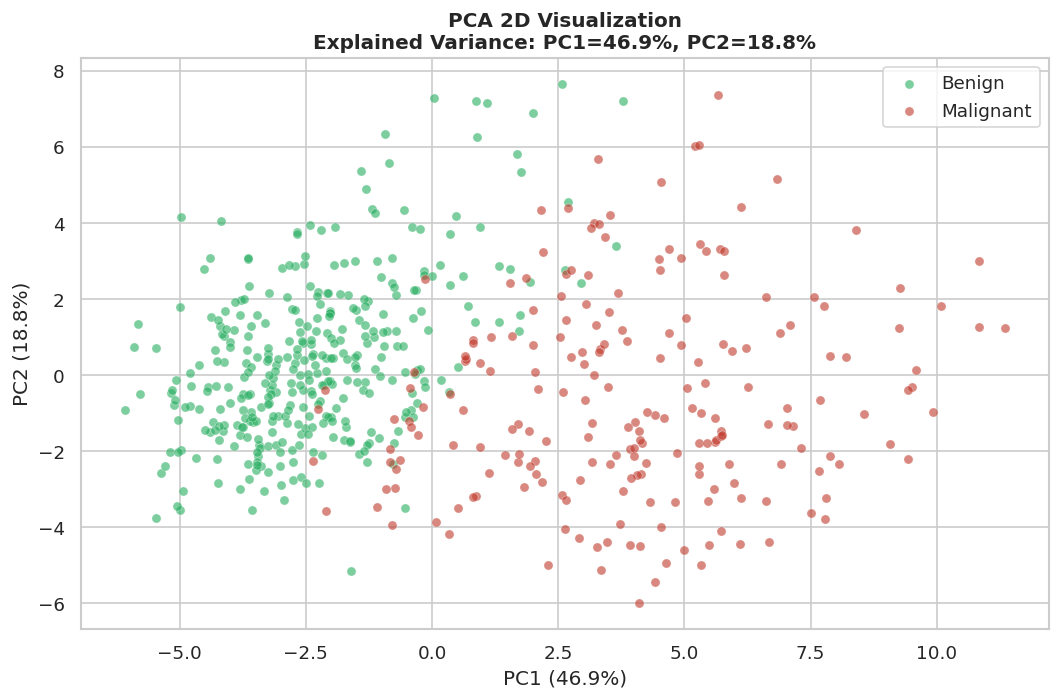

In [18]:
from sklearn.preprocessing import StandardScaler as SS

X_vis = df.drop(columns=['diagnosis'])
y_vis = df['diagnosis']

sc_vis  = SS()
X_sc    = sc_vis.fit_transform(X_vis)

pca_vis = PCA(n_components=2, random_state=42)
X_pca   = pca_vis.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = {'B': '#27ae60', 'M': '#c0392b'}

for label, color in colors.items():
    mask = y_vis == label
    name = 'Benign' if label == 'B' else 'Malignant'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=name,
               alpha=0.6, s=30, edgecolors='white',
               linewidths=0.3)

ax.set_title(
    f'PCA 2D Visualization\n'
    f'Explained Variance: PC1={pca_vis.explained_variance_ratio_[0]*100:.1f}%'
    f', PC2={pca_vis.explained_variance_ratio_[1]*100:.1f}%',
    fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig('SVM_07_pca_2d.png', bbox_inches='tight')
plt.show()

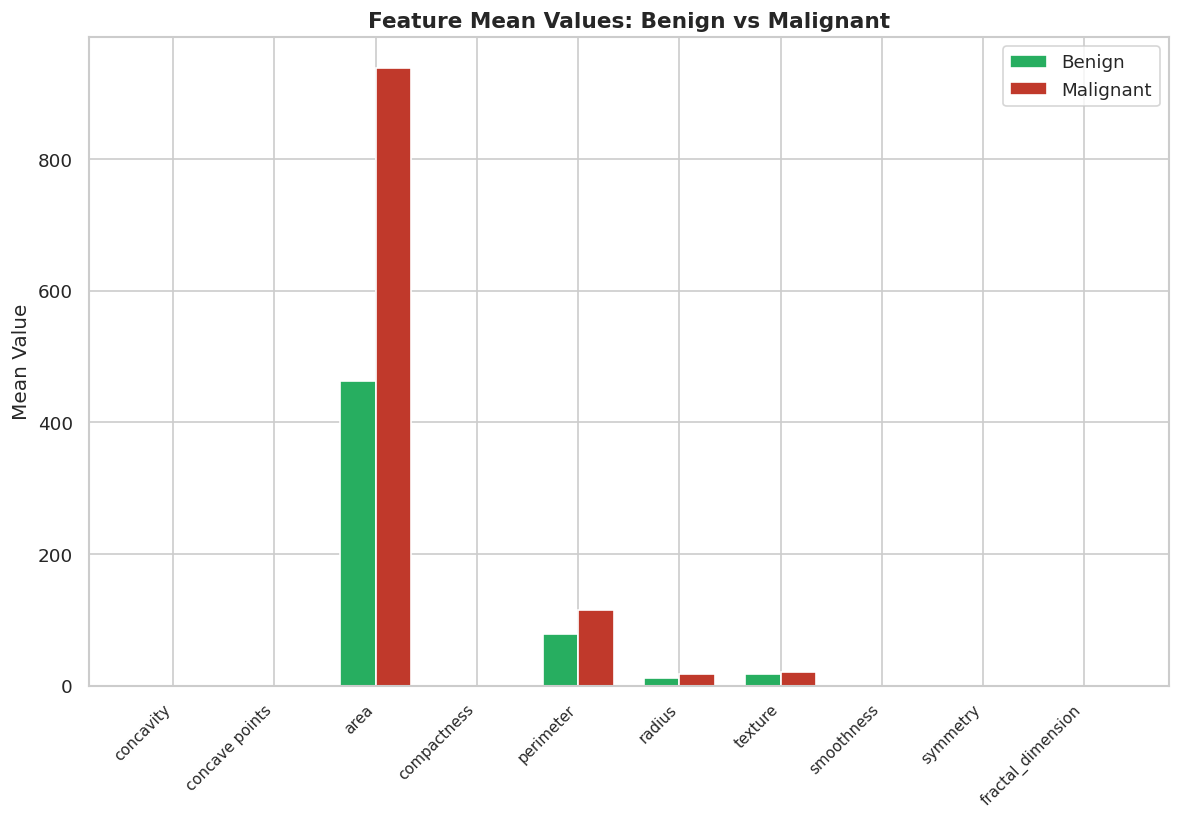

In [19]:
mean_by_diag = df.groupby('diagnosis')[
    [c for c in df.columns if '_mean' in c]
].mean().T

mean_by_diag.columns = ['Benign', 'Malignant']
mean_by_diag['Ratio_M_B'] = (mean_by_diag['Malignant'] /
                               mean_by_diag['Benign'])
mean_by_diag = mean_by_diag.sort_values(
    'Ratio_M_B', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(mean_by_diag))
width = 0.35

bars1 = ax.bar(x - width/2,
               mean_by_diag['Benign'],
               width, label='Benign',
               color='#27ae60', edgecolor='white')
bars2 = ax.bar(x + width/2,
               mean_by_diag['Malignant'],
               width, label='Malignant',
               color='#c0392b', edgecolor='white')

ax.set_title('Feature Mean Values: Benign vs Malignant',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(
    [c.replace('_mean', '') for c in mean_by_diag.index],
    rotation=45, ha='right', fontsize=9)
ax.legend()
ax.set_ylabel('Mean Value')
plt.tight_layout()
plt.savefig('SVM_08_feature_mean_comparison.png',
            bbox_inches='tight')
plt.show()

In [20]:
df_model = df.copy()

# ── 6.1 Encode Target
le = LabelEncoder()
df_model['diagnosis'] = le.fit_transform(df_model['diagnosis'])
# B=0 (Benign), M=1 (Malignant)
print(f"✅ Target encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"   B (Benign) = 0, M (Malignant) = 1")

# ── 6.2 Check remaining categoricals
cat_remaining = df_model.select_dtypes(
    include='object').columns.tolist()
if cat_remaining:
    df_model = pd.get_dummies(
        df_model, columns=cat_remaining, drop_first=True)
    print(f"✅ One-hot encoded: {cat_remaining}")
else:
    print("✅ No additional categorical columns")

# ── 6.3 Handle remaining nulls
df_model.fillna(df_model.median(numeric_only=True),
                inplace=True)

print(f"\n📐 Shape after encoding: {df_model.shape}")
df_model.head(3)

✅ Target encoded: {'B': np.int64(0), 'M': np.int64(1)}
   B (Benign) = 0, M (Malignant) = 1
✅ No additional categorical columns

📐 Shape after encoding: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.22862,0.28241,0.14710,0.2419,...,25.38,17.33,184.6,1937.05,0.1622,0.62695,0.7119,0.2654,0.41915,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.8,1937.05,0.1238,0.18660,0.2416,0.1860,0.27500,0.08902
2,1,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.5,1709.00,0.1444,0.42450,0.4504,0.2430,0.36130,0.08758


In [21]:
# Radius to area ratio
if ('radius_mean' in df_model.columns and
        'area_mean' in df_model.columns):
    df_model['radius_area_ratio'] = (
        df_model['radius_mean'] /
        (df_model['area_mean'] + 1e-5))
    print("✅ 'radius_area_ratio' created")

# Compactness index
if ('perimeter_mean' in df_model.columns and
        'area_mean' in df_model.columns):
    df_model['compactness_index'] = (
        df_model['perimeter_mean'] ** 2 /
        (4 * np.pi * df_model['area_mean'] + 1e-5))
    print("✅ 'compactness_index' created")

# Mean of all _mean features
mean_feat_cols = [c for c in df_model.columns
                  if '_mean' in c]
df_model['overall_mean_score'] = df_model[
    mean_feat_cols].mean(axis=1)
print("✅ 'overall_mean_score' created")

# Worst to mean ratio (severity indicator)
worst_cols = [c for c in df_model.columns if '_worst' in c]
mean_cols_all = [c for c in df_model.columns if '_mean' in c
                 and 'overall' not in c]
if len(worst_cols) == len(mean_cols_all):
    df_model['worst_mean_ratio'] = (
        df_model[worst_cols].mean(axis=1) /
        (df_model[mean_cols_all].mean(axis=1) + 1e-5))
    print("✅ 'worst_mean_ratio' created")

print(f"\n📐 Final Shape: {df_model.shape}")

✅ 'radius_area_ratio' created
✅ 'compactness_index' created
✅ 'overall_mean_score' created
✅ 'worst_mean_ratio' created

📐 Final Shape: (569, 35)


In [22]:
X = df_model.drop(columns=['diagnosis'])
y = df_model['diagnosis']

print(f"🎯 Target distribution:")
print(f"   Benign (0)    : {(y==0).sum()}")
print(f"   Malignant (1) : {(y==1).sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

# ⚠️ SVM MUST have scaling — very important!
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n✅ Training set  : {X_train_sc.shape}")
print(f"✅ Test set      : {X_test_sc.shape}")
print(f"✅ Features      : {X_train_sc.shape[1]}")
print("\n⚠️  StandardScaler APPLIED — SVM এর জন্য অবশ্যই দরকার!")

🎯 Target distribution:
   Benign (0)    : 357
   Malignant (1) : 212

✅ Training set  : (455, 34)
✅ Test set      : (114, 34)
✅ Features      : 34

⚠️  StandardScaler APPLIED — SVM এর জন্য অবশ্যই দরকার!


In [23]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results = {}

for kernel in kernels:
    svm_temp = SVC(
        kernel       = kernel,
        probability  = True,
        random_state = 42,
        class_weight = 'balanced'
    )
    svm_temp.fit(X_train_sc, y_train)
    y_p  = svm_temp.predict(X_test_sc)
    y_pp = svm_temp.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_p)
    roc = roc_auc_score(y_test, y_pp)
    kernel_results[kernel] = {
        'acc': acc, 'roc': roc, 'model': svm_temp}

    print(f"  {kernel:<10} → Accuracy: {acc*100:.2f}%  "
          f"ROC-AUC: {roc:.4f}")

best_kernel = max(kernel_results,
                  key=lambda k: kernel_results[k]['roc'])
print(f"\n🏆 Best Kernel (by ROC-AUC): {best_kernel}")

  linear     → Accuracy: 98.25%  ROC-AUC: 0.9954
  rbf        → Accuracy: 98.25%  ROC-AUC: 0.9974
  poly       → Accuracy: 92.11%  ROC-AUC: 0.9983
  sigmoid    → Accuracy: 94.74%  ROC-AUC: 0.9947

🏆 Best Kernel (by ROC-AUC): poly


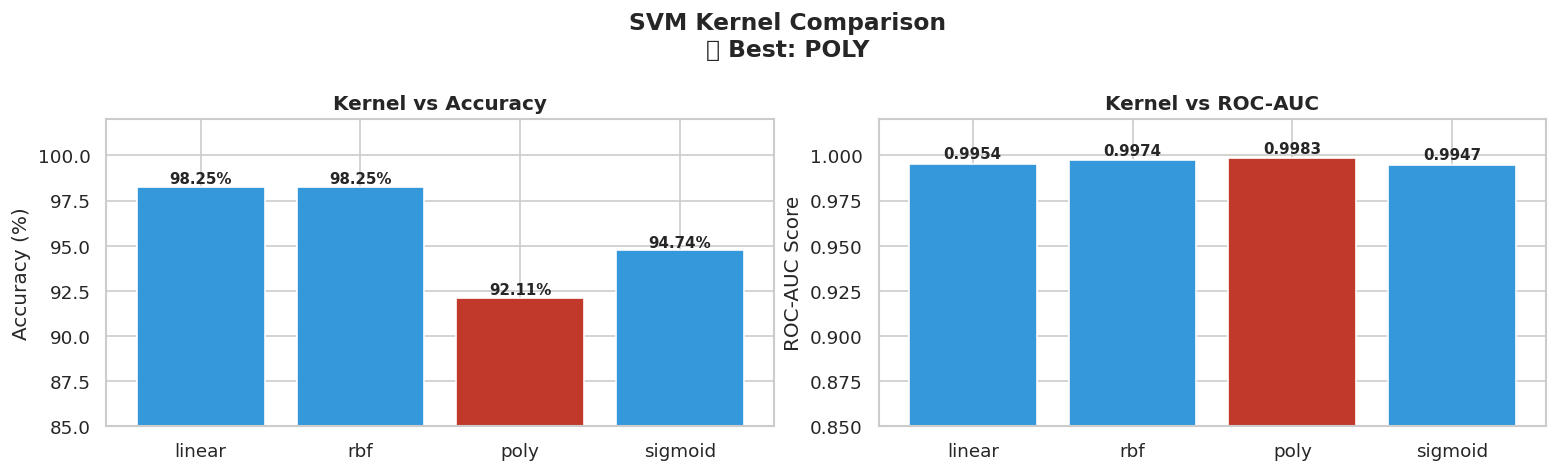

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_names = list(kernel_results.keys())
k_acc   = [kernel_results[k]['acc'] * 100 for k in k_names]
k_roc   = [kernel_results[k]['roc'] for k in k_names]

colors  = ['#c0392b' if k == best_kernel
           else '#3498db' for k in k_names]

axes[0].bar(k_names, k_acc, color=colors, edgecolor='white')
axes[0].set_title('Kernel vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(85, 102)
for i, v in enumerate(k_acc):
    axes[0].text(i, v + 0.2, f'{v:.2f}%',
                 ha='center', fontweight='bold', fontsize=9)

axes[1].bar(k_names, k_roc, color=colors, edgecolor='white')
axes[1].set_title('Kernel vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].set_ylim(0.85, 1.02)
for i, v in enumerate(k_roc):
    axes[1].text(i, v + 0.003, f'{v:.4f}',
                 ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'SVM Kernel Comparison\n'
             f'🏆 Best: {best_kernel.upper()}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SVM_09_kernel_comparison.png',
            bbox_inches='tight')
plt.show()

In [25]:
# Tune best kernel (RBF usually best)
param_grid = {
    'C'      : [0.01, 0.1, 1, 10, 50, 100],
    'gamma'  : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel' : [best_kernel]
}

# Add degree if poly is best
if best_kernel == 'poly':
    param_grid['degree'] = [2, 3, 4]

grid_search = GridSearchCV(
    estimator = SVC(
        probability  = True,
        random_state = 42,
        class_weight = 'balanced'),
    param_grid = param_grid,
    cv         = StratifiedKFold(5),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train_sc, y_train)

print(f"\n✅ Best Parameters : {grid_search.best_params_}")
print(f"✅ Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Best Parameters : {'C': 10, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}
✅ Best CV ROC-AUC : 0.9946


In [26]:
svm_best = grid_search.best_estimator_
svm_best.fit(X_train_sc, y_train)

y_pred      = svm_best.predict(X_test_sc)
y_pred_prob = svm_best.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)
cv  = cross_val_score(svm_best, X_train_sc, y_train,
                      cv=StratifiedKFold(5),
                      scoring='roc_auc')

# Baseline best kernel result
base_acc = kernel_results[best_kernel]['acc']
base_roc = kernel_results[best_kernel]['roc']

print(f"\n{'Metric':<30} {'Baseline':>10} {'Tuned':>10}")
print("-" * 52)
print(f"{'Accuracy':<30} {base_acc*100:>9.2f}% {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<30} {base_roc:>10.4f} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<30} {'—':>10} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<30} {'—':>10} {cv.std():>10.4f}")
print(f"{'Support Vectors':<30} "
      f"{sum(kernel_results[best_kernel]['model'].n_support_):>10} "
      f"{sum(svm_best.n_support_):>10}")

print(f"\n📋 Classification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=['Benign', 'Malignant']))


Metric                           Baseline      Tuned
----------------------------------------------------
Accuracy                           92.11%     94.74%
ROC-AUC                            0.9983     0.9987
CV ROC-AUC (mean)                       —     0.9946
CV ROC-AUC (std)                        —     0.0057
Support Vectors                       142         84

📋 Classification Report:

              precision    recall  f1-score   support

      Benign       0.92      1.00      0.96        72
   Malignant       1.00      0.86      0.92        42

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



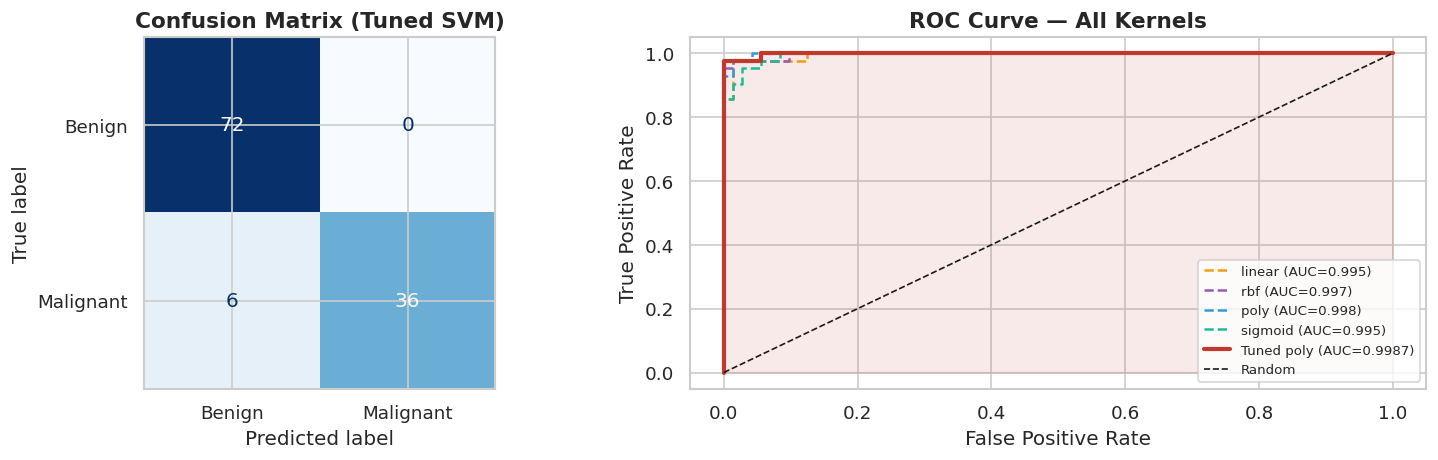

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Tuned SVM)',
                  fontsize=13, fontweight='bold')

# ROC — all kernels
colors_roc = ['#f39c12', '#9b59b6', '#3498db', '#1abc9c']
for (kernel, res), color in zip(
        kernel_results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(
        y_test,
        res['model'].predict_proba(X_test_sc)[:, 1])
    axes[1].plot(fpr, tpr, lw=1.5, color=color,
                 linestyle='--',
                 label=f'{kernel} (AUC={res["roc"]:.3f})')

# Tuned model ROC
fpr_t, tpr_t, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr_t, tpr_t, color='#c0392b', lw=2.5,
             label=f'Tuned {best_kernel} (AUC={roc:.4f})')
axes[1].fill_between(fpr_t, tpr_t,
                     alpha=0.1, color='#c0392b')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — All Kernels',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('SVM_10_confusion_roc.png', bbox_inches='tight')
plt.show()

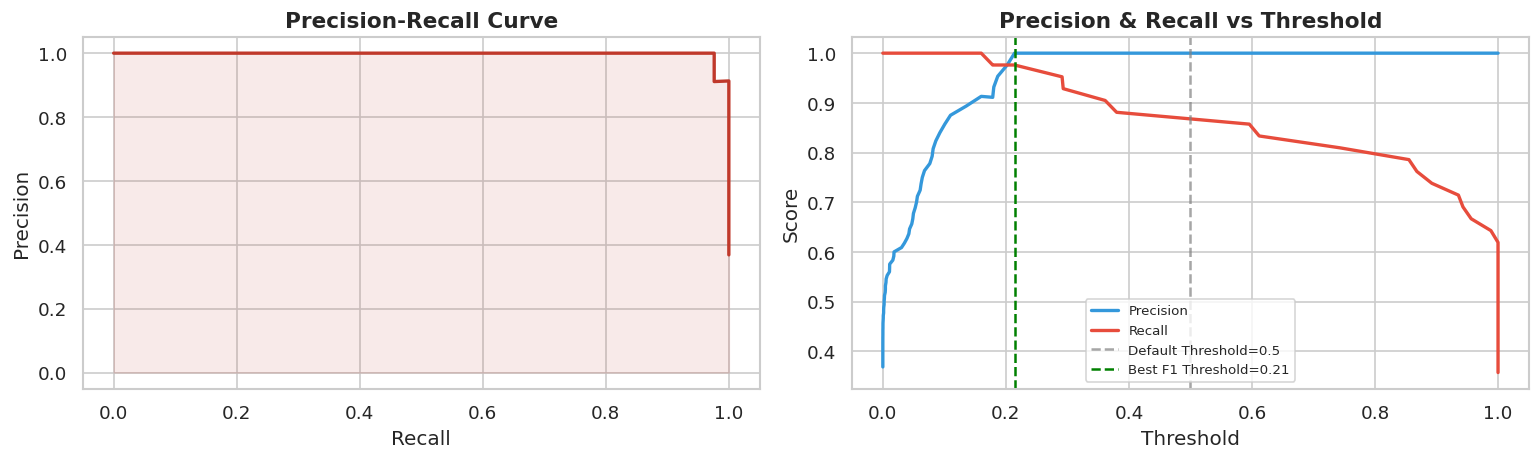

💾 Saved: SVM_11_precision_recall.png
📌 Best F1 Threshold: 0.2141


In [28]:
precision, recall, thresholds = precision_recall_curve(
    y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PR Curve
axes[0].plot(recall, precision,
             color='#c0392b', lw=2)
axes[0].fill_between(recall, precision,
                     alpha=0.1, color='#c0392b')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve',
                  fontsize=13, fontweight='bold')

# Threshold Analysis
axes[1].plot(thresholds, precision[:-1],
             color='#3498db', lw=2, label='Precision')
axes[1].plot(thresholds, recall[:-1],
             color='#e74c3c', lw=2, label='Recall')
axes[1].axvline(x=0.5, color='gray',
                linestyle='--', alpha=0.7,
                label='Default Threshold=0.5')
f1_scores = (2 * precision[:-1] * recall[:-1] /
             (precision[:-1] + recall[:-1] + 1e-8))
best_thresh = thresholds[np.argmax(f1_scores)]
axes[1].axvline(x=best_thresh, color='green',
                linestyle='--',
                label=f'Best F1 Threshold={best_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('SVM_11_precision_recall.png',
            bbox_inches='tight')
plt.show()
print("💾 Saved: SVM_11_precision_recall.png")
print(f"📌 Best F1 Threshold: {best_thresh:.4f}")

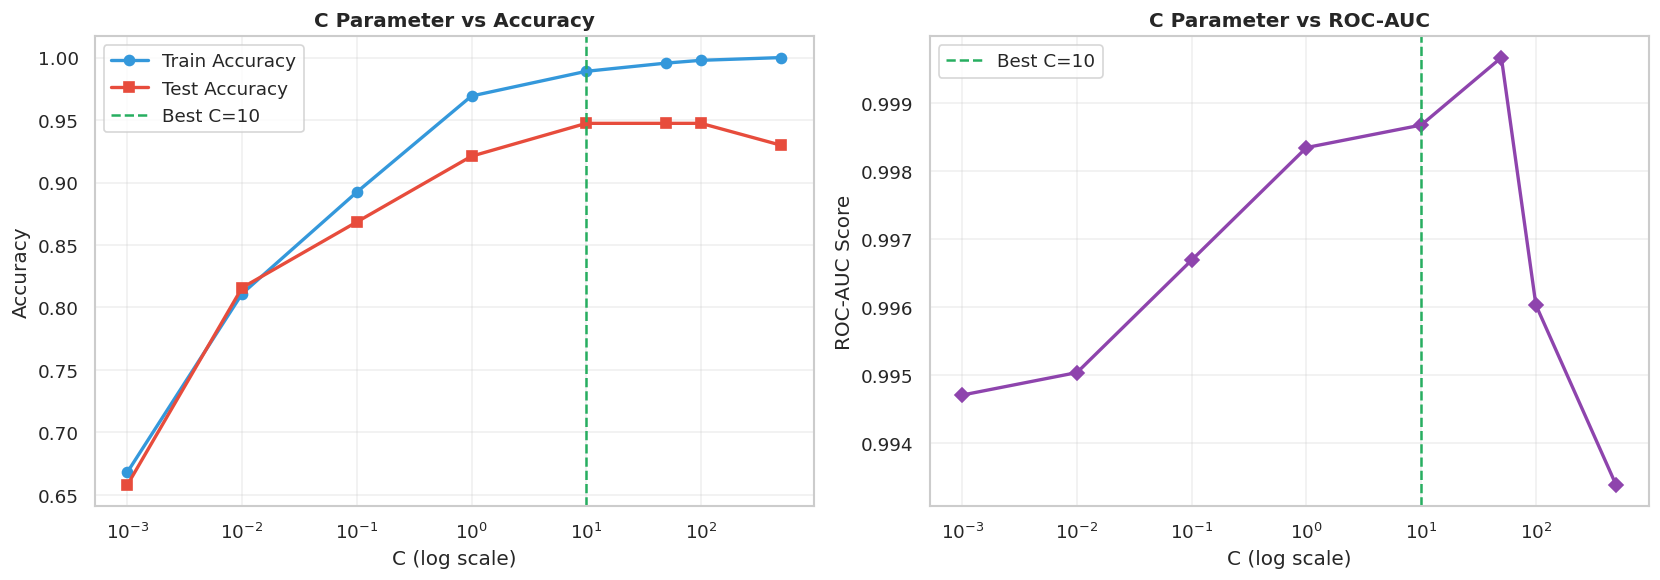

In [29]:
C_range    = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
train_accs = []
test_accs  = []
test_rocs  = []

for C_val in C_range:
    svm_c = SVC(
        kernel       = best_kernel,
        C            = C_val,
        gamma        = grid_search.best_params_.get(
                           'gamma', 'scale'),
        probability  = True,
        random_state = 42,
        class_weight = 'balanced'
    )
    svm_c.fit(X_train_sc, y_train)
    train_accs.append(
        accuracy_score(y_train, svm_c.predict(X_train_sc)))
    test_accs.append(
        accuracy_score(y_test, svm_c.predict(X_test_sc)))
    test_rocs.append(
        roc_auc_score(
            y_test,
            svm_c.predict_proba(X_test_sc)[:, 1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(C_range, train_accs, 'o-',
                 color='#3498db', lw=2,
                 label='Train Accuracy')
axes[0].semilogx(C_range, test_accs, 's-',
                 color='#e74c3c', lw=2,
                 label='Test Accuracy')
axes[0].axvline(
    x=grid_search.best_params_['C'],
    color='#27ae60', linestyle='--',
    label=f"Best C={grid_search.best_params_['C']}")
axes[0].set_title('C Parameter vs Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(C_range, test_rocs, 'D-',
                 color='#8e44ad', lw=2)
axes[1].axvline(
    x=grid_search.best_params_['C'],
    color='#27ae60', linestyle='--',
    label=f"Best C={grid_search.best_params_['C']}")
axes[1].set_title('C Parameter vs ROC-AUC',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('C (log scale)')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SVM_12_C_analysis.png', bbox_inches='tight')
plt.show()

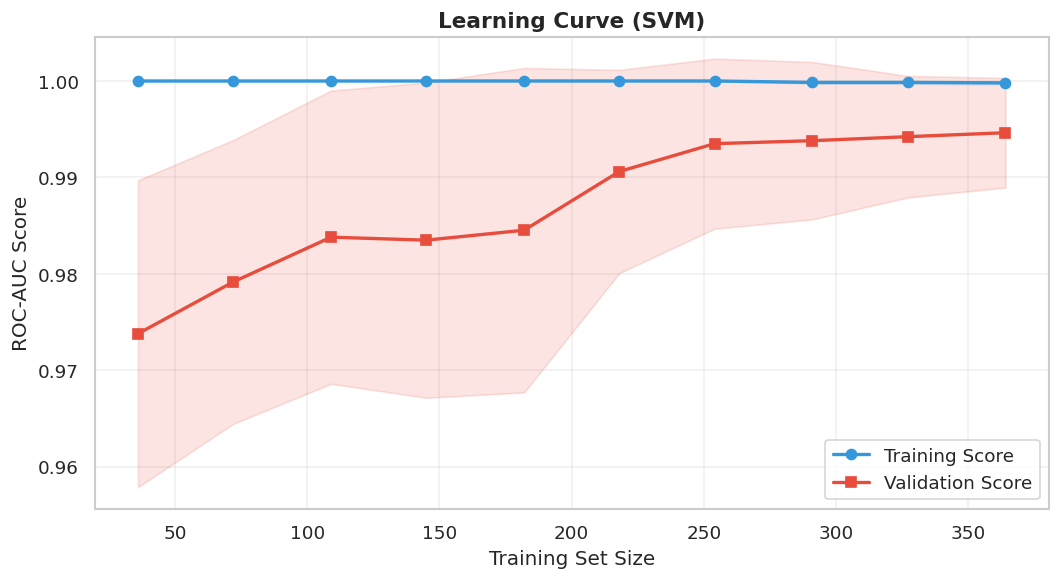

In [30]:
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    svm_best, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(5),
    scoring='roc_auc',
    n_jobs=-1)

train_mean = train_scores_lc.mean(axis=1)
train_std  = train_scores_lc.std(axis=1)
val_mean   = val_scores_lc.mean(axis=1)
val_std    = val_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-',
        color='#3498db', lw=2, label='Training Score')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.plot(train_sizes, val_mean, 's-',
        color='#e74c3c', lw=2, label='Validation Score')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#e74c3c')
ax.set_title('Learning Curve (SVM)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('ROC-AUC Score')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('SVM_13_learning_curve.png', bbox_inches='tight')
plt.show()

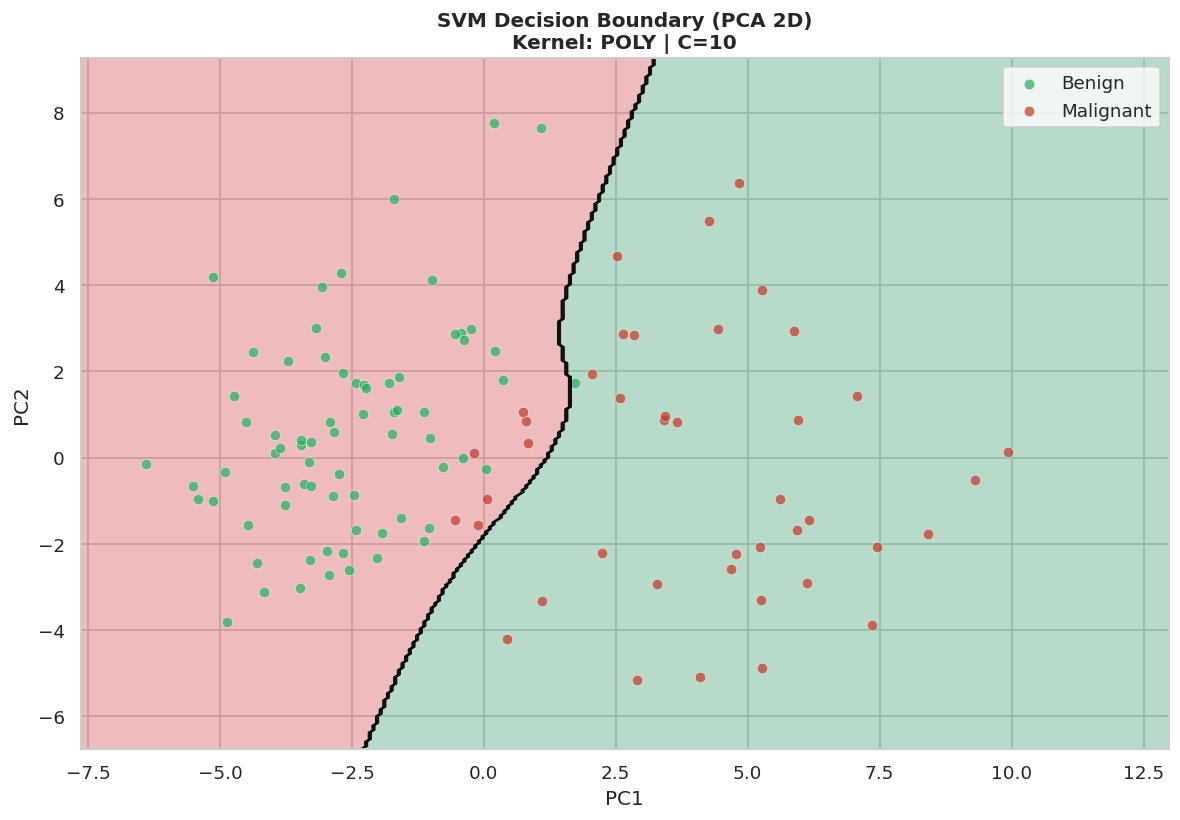

In [31]:
pca_2d     = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_sc)
X_test_2d  = pca_2d.transform(X_test_sc)

svm_2d = SVC(
    kernel       = best_kernel,
    C            = grid_search.best_params_['C'],
    gamma        = grid_search.best_params_.get(
                       'gamma', 'scale'),
    probability  = True,
    random_state = 42,
    class_weight = 'balanced'
)
svm_2d.fit(X_train_2d, y_train)

# Meshgrid
x_min = X_train_2d[:, 0].min() - 1
x_max = X_train_2d[:, 0].max() + 1
y_min = X_train_2d[:, 1].min() - 1
y_max = X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300))

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z,
            cmap=plt.cm.RdYlGn, alpha=0.3)
ax.contour(xx, yy, Z,
           colors='black', linewidths=0.5)

for label, color, name in zip(
        [0, 1],
        ['#27ae60', '#c0392b'],
        ['Benign', 'Malignant']):
    mask = y_test == label
    ax.scatter(X_test_2d[mask, 0],
               X_test_2d[mask, 1],
               c=color, label=name,
               alpha=0.7, s=40,
               edgecolors='white', linewidths=0.4)

ax.set_title(
    f'SVM Decision Boundary (PCA 2D)\n'
    f'Kernel: {best_kernel.upper()} | '
    f'C={grid_search.best_params_["C"]}',
    fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.savefig('SVM_14_decision_boundary.png',
            bbox_inches='tight')
plt.show()

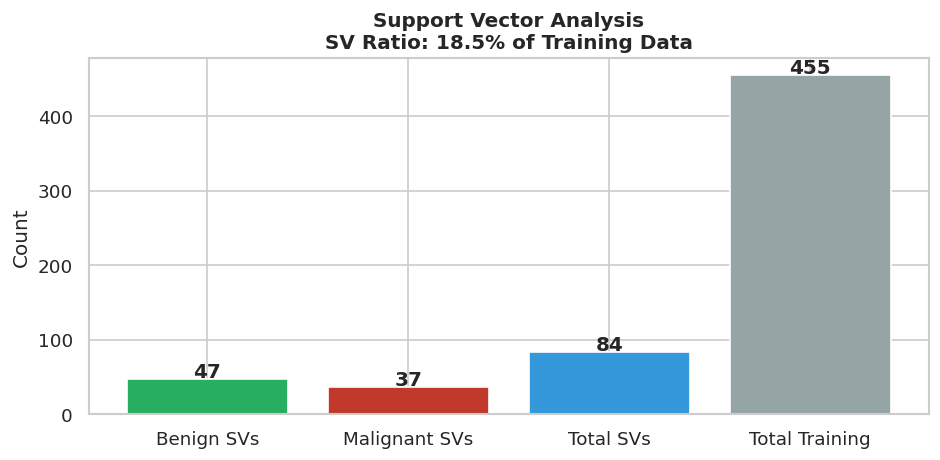

💾 Saved: SVM_15_support_vectors.png

📌 Support Vector Details:
   Benign SVs     : 47
   Malignant SVs  : 37
   Total SVs      : 84
   SV Ratio       : 18.5%


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

sv_per_class = svm_best.n_support_
total_sv     = sum(sv_per_class)
total_train  = X_train_sc.shape[0]

categories   = ['Benign SVs', 'Malignant SVs',
                 'Total SVs', 'Total Training']
values       = [sv_per_class[0], sv_per_class[1],
                total_sv, total_train]
colors_sv    = ['#27ae60', '#c0392b', '#3498db', '#95a5a6']

bars = ax.bar(categories, values,
              color=colors_sv, edgecolor='white')
ax.set_title(
    f'Support Vector Analysis\n'
    f'SV Ratio: {total_sv/total_train*100:.1f}% of Training Data',
    fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('SVM_15_support_vectors.png',
            bbox_inches='tight')
plt.show()
print("💾 Saved: SVM_15_support_vectors.png")
print(f"\n📌 Support Vector Details:")
print(f"   Benign SVs     : {sv_per_class[0]}")
print(f"   Malignant SVs  : {sv_per_class[1]}")
print(f"   Total SVs      : {total_sv}")
print(f"   SV Ratio       : {total_sv/total_train*100:.1f}%")

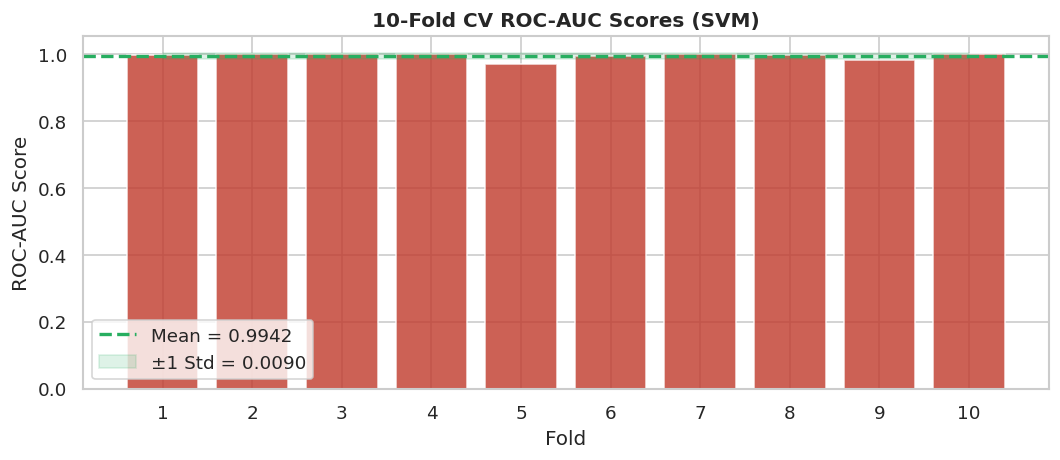

In [33]:
cv_scores_10 = cross_val_score(
    svm_best, X_train_sc, y_train,
    cv=StratifiedKFold(10),
    scoring='roc_auc')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), cv_scores_10,
       color='#c0392b', edgecolor='white', alpha=0.8)
ax.axhline(y=cv_scores_10.mean(),
           color='#27ae60', linestyle='--', lw=2,
           label=f'Mean = {cv_scores_10.mean():.4f}')
ax.fill_between(
    range(1, 11),
    cv_scores_10.mean() - cv_scores_10.std(),
    cv_scores_10.mean() + cv_scores_10.std(),
    alpha=0.15, color='#27ae60',
    label=f'±1 Std = {cv_scores_10.std():.4f}')
ax.set_title('10-Fold CV ROC-AUC Scores (SVM)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC Score')
ax.set_xticks(range(1, 11))
ax.legend()
plt.tight_layout()
plt.savefig('SVM_16_cv_scores.png', bbox_inches='tight')
plt.show()

In [34]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel       = best_kernel,
        C            = grid_search.best_params_['C'],
        gamma        = grid_search.best_params_.get(
                           'gamma', 'scale'),
        probability  = True,
        random_state = 42,
        class_weight = 'balanced'
    ))
])

svm_pipeline.fit(X_train, y_train)

pipe_pred = svm_pipeline.predict(X_test)
pipe_roc  = roc_auc_score(
    y_test,
    svm_pipeline.predict_proba(X_test)[:, 1])

print(f"✅ Pipeline Accuracy : "
      f"{accuracy_score(y_test, pipe_pred)*100:.2f}%")
print(f"✅ Pipeline ROC-AUC  : {pipe_roc:.4f}")
print("✅ Pipeline ready for production use!")

✅ Pipeline Accuracy : 94.74%
✅ Pipeline ROC-AUC  : 0.9987
✅ Pipeline ready for production use!


In [35]:
# Save tuned SVM model
joblib.dump(svm_best, 'svm_cancer_model.pkl')
print("✅ SVM Model saved     → svm_cancer_model.pkl")

# Save full pipeline (scaler + model)
joblib.dump(svm_pipeline, 'svm_pipeline_cancer.pkl')
print("✅ SVM Pipeline saved  → svm_pipeline_cancer.pkl")

# Save scaler separately
joblib.dump(scaler, 'SVM_scaler.pkl')
print("✅ Scaler saved        → SVM_scaler.pkl")

# Save feature names
pd.DataFrame({'features': X.columns.tolist()}).to_csv(
    'SVM_feature_names.csv', index=False)
print("✅ Features saved      → SVM_feature_names.csv")

# Save GridSearch results
pd.DataFrame(grid_search.cv_results_).to_csv(
    'SVM_gridsearch_results.csv', index=False)
print("✅ GridSearch saved    → SVM_gridsearch_results.csv")

# Save label encoder classes
pd.DataFrame({
    'class': le.classes_,
    'encoded': le.transform(le.classes_)
}).to_csv('SVM_label_encoding.csv', index=False)
print("✅ Label encoding saved → SVM_label_encoding.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('svm_cancer_model.pkl')
    files.download('svm_pipeline_cancer.pkl')
    files.download('SVM_scaler.pkl')
    files.download('SVM_feature_names.csv')
    files.download('SVM_gridsearch_results.csv')
    files.download('SVM_label_encoding.csv')
    print("\n🎉 All files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — saved in current directory:")
    print(f"   → {os.path.abspath('svm_cancer_model.pkl')}")
    print(f"   → {os.path.abspath('svm_pipeline_cancer.pkl')}")
    print(f"   → {os.path.abspath('SVM_feature_names.csv')}")

✅ SVM Model saved     → svm_cancer_model.pkl
✅ SVM Pipeline saved  → svm_pipeline_cancer.pkl
✅ Scaler saved        → SVM_scaler.pkl
✅ Features saved      → SVM_feature_names.csv
✅ GridSearch saved    → SVM_gridsearch_results.csv
✅ Label encoding saved → SVM_label_encoding.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All files downloaded to your PC!


In [36]:
# Load pipeline (recommended — includes scaler)
loaded_pipeline = joblib.load('svm_pipeline_cancer.pkl')

sample      = X_test.iloc[:5]
predictions = loaded_pipeline.predict(sample)
proba       = loaded_pipeline.predict_proba(sample)[:, 1]
actuals     = y_test.values[:5]

print("\n📊 Sample Predictions:")
print(f"{'#':<4} {'Prediction':<18} {'Malignant Prob':>15}"
      f" {'Actual':>12}")
print("-" * 53)

for i, (pred, prob, actual) in enumerate(
        zip(predictions, proba, actuals)):
    label    = "🔴 MALIGNANT" if pred == 1 else "🟢 BENIGN"
    act_label = "MALIGNANT"   if actual == 1 else "BENIGN"
    print(f"{i+1:<4} {label:<18} {prob*100:>14.2f}%"
          f" {act_label:>12}")

print("\n✅ Model loaded and working perfectly!")


📊 Sample Predictions:
#    Prediction          Malignant Prob       Actual
-----------------------------------------------------
1    🟢 BENIGN                     0.07%       BENIGN
2    🔴 MALIGNANT                100.00%    MALIGNANT
3    🟢 BENIGN                    10.07%       BENIGN
4    🟢 BENIGN                    29.14%    MALIGNANT
5    🟢 BENIGN                     7.64%       BENIGN

✅ Model loaded and working perfectly!


In [37]:
print(f"  Dataset           : Breast Cancer Wisconsin")
print(f"  Dataset Shape     : {df.shape}")
print(f"  Features Used     : {X.shape[1]}")
print(f"  Training Samples  : {X_train_sc.shape[0]}")
print(f"  Test Samples      : {X_test_sc.shape[0]}")
print(f"  Best Kernel       : {best_kernel.upper()}")
print(f"  Best Parameters   : {grid_search.best_params_}")
print(f"  Baseline Accuracy : {base_acc*100:.2f}%")
print(f"  Tuned Accuracy    : {acc*100:.2f}%")
print(f"  Baseline ROC-AUC  : {base_roc:.4f}")
print(f"  Tuned ROC-AUC     : {roc:.4f}")
print(f"  CV ROC-AUC        : {cv.mean():.4f} ± {cv.std():.4f}")
print(f"  Support Vectors   : {total_sv} "
      f"({total_sv/total_train*100:.1f}% of train)")
print(f"  Best F1 Threshold : {best_thresh:.4f}")

print(" Saved Files:")
print("   svm_cancer_model.pkl")
print("   svm_pipeline_cancer.pkl  ← Production use!")
print("   SVM_scaler.pkl")
print("   SVM_feature_names.csv")
print("   SVM_gridsearch_results.csv")
print("    SVM_label_encoding.csv")
print("    SVM_01 ~ SVM_16 PNG files")

print("✅ SVM Pipeline Complete! 🎯")

  Dataset           : Breast Cancer Wisconsin
  Dataset Shape     : (569, 31)
  Features Used     : 34
  Training Samples  : 455
  Test Samples      : 114
  Best Kernel       : POLY
  Best Parameters   : {'C': 10, 'degree': 3, 'gamma': 'auto', 'kernel': 'poly'}
  Baseline Accuracy : 92.11%
  Tuned Accuracy    : 94.74%
  Baseline ROC-AUC  : 0.9983
  Tuned ROC-AUC     : 0.9987
  CV ROC-AUC        : 0.9946 ± 0.0057
  Support Vectors   : 84 (18.5% of train)
  Best F1 Threshold : 0.2141
 Saved Files:
   svm_cancer_model.pkl
   svm_pipeline_cancer.pkl  ← Production use!
   SVM_scaler.pkl
   SVM_feature_names.csv
   SVM_gridsearch_results.csv
    SVM_label_encoding.csv
    SVM_01 ~ SVM_16 PNG files
✅ SVM Pipeline Complete! 🎯
